In [1]:
import os
import time
import sqlite3
import builtins

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import *
from pyspark.sql.types import *

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier,
    RandomForestClassifier, GBTClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator,
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.functions import vector_to_array

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

os.environ["PYSPARK_PYTHON"] = "python"
sns.set_style("whitegrid")

# All figures / DB / model exports go here - create it up front so savefig()
# and sqlite3.connect() never fail on a fresh checkout.
os.makedirs("output", exist_ok=True)


In [2]:
spark = SparkSession.builder.appName("Exploring") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/22 07:54:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/22 07:54:56 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## 1. Data Loading & Initial Exploration

In [3]:
df_orgs = spark.read.option("header", True).option("inferSchema", True) \
    .csv("data/raw/organisations_data_catalogue.csv")
df_orgs.printSchema()
df_orgs.show(5)


root
 |-- Name: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Date Invite Accepted: timestamp (nullable = true)
 |-- Organisation creation date: timestamp (nullable = true)
 |-- Date Invited: timestamp (nullable = true)
 |-- Last Log-In: timestamp (nullable = true)
 |-- Permit Holder: string (nullable = true)
 |-- National Operator Codes: string (nullable = true)
 |-- Licence Numbers: string (nullable = true)
 |-- Number of Licences: integer (nullable = true)
 |-- Unregistered Services: double (nullable = true)
 |-- OTC Registered Services: double (nullable = true)
 |-- Out of scope services(exempted): double (nullable = true)
 |-- Registered Services in scope(for BODS): double (nullable = true)
 |-- Registered Services Published: double (nullable = true)
 |-- Compliant Registered Services Published: double (nullable = true)
 |-- % Compliant Registered Services Published: string (nullable = true)
 |-- Number of School or Works Services: double (nullable = true)
 |

26/07/22 07:54:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [4]:
df_orgs.select(
    regexp_replace(col("% Compliant Registered Services Published"), "%", "").cast("double").alias("compliant"),
    regexp_replace(col("% Compliant Published Fare Datasets"), "%", "").cast("double").alias("fares_compliant"),
).show(5)


+---------+---------------+
|compliant|fares_compliant|
+---------+---------------+
|      0.0|            0.0|
|    85.19|           50.0|
|    55.56|          100.0|
|      0.0|           50.0|
|      0.0|            0.0|
+---------+---------------+
only showing top 5 rows


In [5]:
df_orgs = df_orgs.withColumn(
    "compliant",
    regexp_replace(col("% Compliant Registered Services Published"), "%", "").cast("double"),
).withColumn(
    "fares_compliant",
    regexp_replace(col("% Compliant Published Fare Datasets"), "%", "").cast("double"),
)
df_orgs.printSchema()


root
 |-- Name: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Date Invite Accepted: timestamp (nullable = true)
 |-- Organisation creation date: timestamp (nullable = true)
 |-- Date Invited: timestamp (nullable = true)
 |-- Last Log-In: timestamp (nullable = true)
 |-- Permit Holder: string (nullable = true)
 |-- National Operator Codes: string (nullable = true)
 |-- Licence Numbers: string (nullable = true)
 |-- Number of Licences: integer (nullable = true)
 |-- Unregistered Services: double (nullable = true)
 |-- OTC Registered Services: double (nullable = true)
 |-- Out of scope services(exempted): double (nullable = true)
 |-- Registered Services in scope(for BODS): double (nullable = true)
 |-- Registered Services Published: double (nullable = true)
 |-- Compliant Registered Services Published: double (nullable = true)
 |-- % Compliant Registered Services Published: string (nullable = true)
 |-- Number of School or Works Services: double (nullable = true)
 |

In [6]:
overall_schema = StructType([
    StructField("Operator", StringType(), True),
    StructField("Operator ID", DoubleType(), True),
    StructField("Profile NOCs", StringType(), True),
    StructField("Data Type", StringType(), True),
    StructField("Status", StringType(), True),
    StructField("Last Updated", StringType(), True),
    StructField("File Name", StringType(), True),
    StructField("XML File Name", StringType(), True),
    StructField("Data Set/Feed Name", StringType(), True),
    StructField("Data ID", DoubleType(), True),
    StructField("Mode", StringType(), True),
    StructField("National Operator Code", StringType(), True),
    StructField("Service Code", StringType(), True),
    StructField("Line Name", StringType(), True),
    StructField("Licence Number", StringType(), True),
    StructField("Public Use Flag", StringType(), True),
    StructField("Revision Number", DoubleType(), True),
    StructField("Operating Period Start Date", StringType(), True),
    StructField("Operating Period End Date", StringType(), True),
    StructField("% AVL to Timetables feed matching score", DoubleType(), True),
    StructField("Latest matching report URL", StringType(), True),
])


In [7]:

df_big = spark.read.option("header", True) \
    .option("multiLine", True) \
    .option("escape", '"') \
    .schema(overall_schema) \
    .csv("data/raw/overall_data_catalogue.csv")

df_big.printSchema()
df_big.show(5)
print("df_big rows:", df_big.count())


root
 |-- Operator: string (nullable = true)
 |-- Operator ID: double (nullable = true)
 |-- Profile NOCs: string (nullable = true)
 |-- Data Type: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- File Name: string (nullable = true)
 |-- XML File Name: string (nullable = true)
 |-- Data Set/Feed Name: string (nullable = true)
 |-- Data ID: double (nullable = true)
 |-- Mode: string (nullable = true)
 |-- National Operator Code: string (nullable = true)
 |-- Service Code: string (nullable = true)
 |-- Line Name: string (nullable = true)
 |-- Licence Number: string (nullable = true)
 |-- Public Use Flag: string (nullable = true)
 |-- Revision Number: double (nullable = true)
 |-- Operating Period Start Date: string (nullable = true)
 |-- Operating Period End Date: string (nullable = true)
 |-- % AVL to Timetables feed matching score: double (nullable = true)
 |-- Latest matching report URL: string (nullable = true)

+--------

[Stage 5:>                                                          (0 + 1) / 1]

df_big rows: 795195


In [8]:
df_compliance = spark.read.option("header", True).option("inferSchema", True) \
    .option("multiLine", True).option("escape", '"') \
    .csv("data/raw/overall_compliance_report.csv")

df_timetables = spark.read.option("header", True).option("inferSchema", True) \
    .option("multiLine", True).option("escape", '"') \
    .csv("data/raw/timetables_data_catalogue.csv")

df_fares = spark.read.option("header", True).option("inferSchema", True) \
    .option("multiLine", True).option("escape", '"') \
    .csv("data/raw/fares_data_catalogue.csv")

df_location = spark.read.option("header", True).option("inferSchema", True) \
    .csv("data/raw/location_data_catalogue.csv")

df_disruptions = spark.read.option("header", True).option("inferSchema", True) \
    .option("multiLine", True).option("escape", '"') \
    .csv("data/raw/disruptions_data_catalogue.csv")

df_noc = spark.read.option("header", True).option("inferSchema", True) \
    .csv("data/raw/operator_noc_data_catalogue.csv")


In [9]:
print("df_compliance:  ", df_compliance.count())
print("df_timetables:  ", df_timetables.count())
print("df_fares:       ", df_fares.count())
print("df_location:    ", df_location.count())
print("df_disruptions: ", df_disruptions.count())
print("df_noc:         ", df_noc.count())


df_compliance:   15180
df_timetables:   12861
df_fares:        120207
df_location:     442
df_disruptions:  409
df_noc:          751


## 2. Data Cleaning & Big-Data-Scale Evidence

In [10]:
df_big_clean = (
    df_big
    .filter(col("Operator").isNotNull())
    .withColumn("Status_clean", lower(trim(col("Status"))))
    .withColumn("Last_Updated_ts", to_timestamp(col("Last Updated")))
    .repartition(8, "Operator")
)
df_big_clean.cache()

print("partitions:", df_big_clean.rdd.getNumPartitions())
print("rows:      ", df_big_clean.count())


[Stage 40:==================================================>       (7 + 1) / 8]

partitions: 8
rows:       777956


In [11]:
df_big_clean.describe("% AVL to Timetables feed matching score").show()


+-------+---------------------------------------+
|summary|% AVL to Timetables feed matching score|
+-------+---------------------------------------+
|  count|                                    288|
|   mean|                     61.829861111111114|
| stddev|                       39.6839721020022|
|    min|                                    0.0|
|    max|                                  100.0|
+-------+---------------------------------------+



## 3. Feature Engineering

In [12]:
operator_features = (
    df_big_clean
    .groupBy("Operator")
    .agg(
        F.count("*").alias("op_total_rows"),
        F.sum(F.when(col("Status_clean") == "published", 1).otherwise(0)).alias("op_published_count"),
        F.sum(F.when(col("Status_clean") == "inactive", 1).otherwise(0)).alias("op_inactive_count"),
        F.avg(col("% AVL to Timetables feed matching score")).alias("op_avg_avl_score"),
        F.countDistinct("Line Name").alias("op_distinct_lines"),
    )
)
operator_features.show(10)
print("distinct operators:", operator_features.count())


+--------------------+-------------+------------------+-----------------+----------------+-----------------+
|            Operator|op_total_rows|op_published_count|op_inactive_count|op_avg_avl_score|op_distinct_lines|
+--------------------+-------------+------------------+-----------------+----------------+-----------------+
|           Red Eagle|         2572|               806|             1766|            70.0|               77|
|  Grayscroft Coaches|          150|               127|               23|            87.0|               13|
|Warrington’s Own ...|        21977|              1187|            20790|            96.0|              126|
| Phil Haines Coaches|           14|                 4|               10|             0.0|                6|
|        F R Willetts|           64|                21|               43|             0.0|               10|
|Bland's (Rutland)...|         2463|               850|             1613|            86.0|               23|
|        Libra Trav

In [13]:
CATEGORICAL_COLS = [
    "Registration Status", "Scope Status", "Seasonal Status",
    "Timetables Published Status", "Timetables Timeliness Status",
    "AVL Published Status", "Fares Published Status",
    "Traveline Region", "Local Transport Authority",
]
NUMERIC_COLS = [
    "op_total_rows", "op_published_count", "op_inactive_count",
    "op_avg_avl_score", "op_distinct_lines",
]
SUBSTATUS_COLS = [
    "Timetables Published Status", "Timetables Timeliness Status",
    "AVL Published Status", "Fares Published Status",
]
SAFE_CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c not in SUBSTATUS_COLS]

df_cleaner = (
    df_compliance
    .filter(col("Requires Attention").isin("Yes", "No"))
    .filter(col("Organisation Name").isNotNull())
    .withColumn("label", when(col("Requires Attention") == "Yes", 1.0).otherwise(0.0))
    .dropDuplicates()
)
for c in CATEGORICAL_COLS:
    df_cleaner = df_cleaner.withColumn(c, trim(col(c)))

df_cleaner = df_cleaner.repartition(4)

print("df_cleaner partitions:", df_cleaner.rdd.getNumPartitions())
print("df_cleaner rows:      ", df_cleaner.count())
df_cleaner.groupBy("Requires Attention").count().show()


df_cleaner partitions: 4
df_cleaner rows:       12412
+------------------+-----+
|Requires Attention|count|
+------------------+-----+
|                No| 7407|
|               Yes| 5005|
+------------------+-----+



In [14]:
operator_features_keyed = operator_features.withColumn(
    "org_key", F.upper(F.trim(F.col("Operator")))
)
df_cleaner_keyed = df_cleaner.withColumn(
    "org_key", F.upper(F.trim(F.col("Organisation Name")))
)

ml_table = df_cleaner_keyed.join(
    F.broadcast(operator_features_keyed),
    on="org_key",
    how="left",
)

print("ml_table rows:   ", ml_table.count())
print("unmatched joins: ", ml_table.filter(F.col("op_total_rows").isNull()).count())


ml_table rows:    12412
unmatched joins:  573


In [15]:
ml_table_filled = ml_table.fillna(0, subset=NUMERIC_COLS).fillna("Unknown", subset=CATEGORICAL_COLS)


## 4. Machine Learning Pipeline

In [16]:
def build_feature_pipeline(categorical_cols):
    """Build (but don't fit) a PySpark ML Pipeline: index -> one-hot encode -> assemble -> scale."""
    indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in categorical_cols]
    encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe") for c in categorical_cols]
    assembler = VectorAssembler(
        inputCols=[f"{c}_ohe" for c in categorical_cols] + NUMERIC_COLS,
        outputCol="features_raw", handleInvalid="skip",
    )
    scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=False, withStd=True)
    return Pipeline(stages=indexers + encoders + [assembler, scaler])


def evaluate(name, predictions, secs):
    return {
        "model": name,
        "accuracy": MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy").evaluate(predictions),
        "precision": MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision").evaluate(predictions),
        "recall": MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall").evaluate(predictions),
        "f1": MulticlassClassificationEvaluator(labelCol="label", metricName="f1").evaluate(predictions),
        "roc_auc": BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC").evaluate(predictions),
        "train_secs": secs,
    }


def train_and_compare(categorical_cols, table, label_tag):
    """Fit the feature pipeline once, split, train all 4 classifiers, and evaluate each."""
    pipeline_model = build_feature_pipeline(categorical_cols).fit(table)
    final_df = pipeline_model.transform(table)

    train, test = final_df.randomSplit([0.8, 0.2], seed=42)
    train.cache(); test.cache()
    print(f"[{label_tag}] train: {train.count()}  test: {test.count()}")

    models = {
        "Logistic Regression": LogisticRegression(featuresCol="features", labelCol="label", maxIter=50),
        "Decision Tree": DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=8),
        "Random Forest": RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, maxDepth=10),
        "GBT": GBTClassifier(featuresCol="features", labelCol="label", maxIter=50),
    }

    results, fitted_models = [], {}
    for name, estimator in models.items():
        start = time.time()
        model = estimator.fit(train)
        secs = time.time() - start
        preds = model.transform(test)
        results.append(evaluate(name, preds, secs))
        fitted_models[name] = model

    print(f"\n--- Results: {label_tag} ---")
    for r in results:
        print(f"  {r['model']:<22} acc={r['accuracy']:.3f}  prec={r['precision']:.3f}  "
              f"rec={r['recall']:.3f}  f1={r['f1']:.3f}  auc={r['roc_auc']:.3f}  time={r['train_secs']:.1f}s")

    return {
        "results": results, "fitted_models": fitted_models,
        "pipeline_model": pipeline_model, "final_df": final_df,
        "train": train, "test": test,
    }


## 5. Model Training & Comparison

In [17]:
full_run = train_and_compare(CATEGORICAL_COLS, ml_table_filled, "full (with sub-status flags)")
conservative_run = train_and_compare(SAFE_CATEGORICAL_COLS, ml_table_filled, "conservative (without sub-status flags)")

# "full_run" is the model we save, score, and export below.
results = full_run["results"]
fitted_models = full_run["fitted_models"]
pipeline_model = full_run["pipeline_model"]
final_df = full_run["final_df"]
train, test = full_run["train"], full_run["test"]

results_conservative = conservative_run["results"]


[full (with sub-status flags)] train: 10017  test: 2395


26/07/22 07:55:20 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/07/22 07:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1089.0 KiB
26/07/22 07:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1242.9 KiB
26/07/22 07:55:26 WARN DAGScheduler: Broadcasting large task binary with size 1406.3 KiB
26/07/22 07:55:27 WARN DAGScheduler: Broadcasting large task binary with size 1138.2 KiB
26/07/22 07:55:27 WARN DAGScheduler: Broadcasting large task binary with size 1138.2 KiB
26/07/22 07:55:27 WARN DAGScheduler: Broadcasting large task binary with size 1138.2 KiB
26/07/22 07:55:27 WARN DAGScheduler: Broadcasting large task binary with size 1138.2 KiB
26/07/22 07:55:27 WARN DAGScheduler: Broadcasting large task binary with size 1126.5 KiB



--- Results: full (with sub-status flags) ---
  Logistic Regression    acc=0.908  prec=0.908  rec=0.908  f1=0.908  auc=0.971  time=4.2s
  Decision Tree          acc=0.893  prec=0.898  rec=0.893  f1=0.894  auc=0.919  time=0.9s
  Random Forest          acc=0.909  prec=0.909  rec=0.909  f1=0.909  auc=0.971  time=2.2s
  GBT                    acc=0.937  prec=0.938  rec=0.937  f1=0.937  auc=0.983  time=10.5s
[conservative (without sub-status flags)] train: 10017  test: 2395


26/07/22 07:55:46 WARN DAGScheduler: Broadcasting large task binary with size 1030.1 KiB
26/07/22 07:55:46 WARN DAGScheduler: Broadcasting large task binary with size 1134.0 KiB
26/07/22 07:55:47 WARN DAGScheduler: Broadcasting large task binary with size 1011.8 KiB
26/07/22 07:55:47 WARN DAGScheduler: Broadcasting large task binary with size 1011.8 KiB
26/07/22 07:55:47 WARN DAGScheduler: Broadcasting large task binary with size 1011.8 KiB
26/07/22 07:55:47 WARN DAGScheduler: Broadcasting large task binary with size 1011.8 KiB
26/07/22 07:55:47 WARN DAGScheduler: Broadcasting large task binary with size 1000.0 KiB



--- Results: conservative (without sub-status flags) ---
  Logistic Regression    acc=0.835  prec=0.835  rec=0.835  f1=0.835  auc=0.921  time=2.3s
  Decision Tree          acc=0.857  prec=0.860  rec=0.857  f1=0.855  auc=0.846  time=0.5s
  Random Forest          acc=0.825  prec=0.837  rec=0.825  f1=0.826  auc=0.924  time=1.8s
  GBT                    acc=0.869  prec=0.869  rec=0.869  f1=0.869  auc=0.945  time=8.9s


In [18]:
print(f"{'Model':<22} {'F1 (with flags)':<18} {'F1 (without flags)':<20} {'Drop'}")
for r_full, r_cons in zip(results, results_conservative):
    drop = r_full["f1"] - r_cons["f1"]
    print(f"{r_full['model']:<22} {r_full['f1']:<18.3f} {r_cons['f1']:<20.3f} {drop:+.3f}")


Model                  F1 (with flags)    F1 (without flags)   Drop
Logistic Regression    0.908              0.835                +0.072
Decision Tree          0.894              0.855                +0.039
Random Forest          0.909              0.826                +0.082
GBT                    0.937              0.869                +0.068


In [19]:
best_model_name = builtins.max(results, key=lambda r: r["f1"])["model"]
print("Best model:", best_model_name)
fitted_models[best_model_name].write().overwrite().save("output/best_model")

pdf_ml_table = ml_table_filled.toPandas()
conn = sqlite3.connect("output/bods_processed.db")
pdf_ml_table.to_sql("ml_features", conn, if_exists="replace", index=False)

# Export the full classification comparison (all 4 models, both variants) so the
# dashboard can read real numbers instead of hardcoding them.
metrics_export = pd.DataFrame(results)
metrics_export["variant"] = "full (with sub-status flags)"
metrics_export["is_best"] = metrics_export["model"] == best_model_name

metrics_conservative_export = pd.DataFrame(results_conservative)
metrics_conservative_export["variant"] = "conservative (without sub-status flags)"
metrics_conservative_export["is_best"] = False

pd.concat([metrics_export, metrics_conservative_export], ignore_index=True).to_sql(
    "model_metrics", conn, if_exists="replace", index=False
)

conn.close()
print("Exported to output/bods_processed.db (tables: ml_features, model_metrics)")


Best model: GBT


Exported to output/bods_processed.db (tables: ml_features, model_metrics)


In [20]:
print("df_big:        ", df_big.count())
print("df_big_clean:  ", df_big_clean.count(), "| partitions:", df_big_clean.rdd.getNumPartitions())
print("df_cleaner:    ", df_cleaner.count(), "| partitions:", df_cleaner.rdd.getNumPartitions())
print("ml_table:      ", ml_table.count(), "| unmatched joins:", ml_table.filter(F.col("op_total_rows").isNull()).count())
print("final_df:      ", final_df.count())
for r in results:
    print(r)


df_big:         795195
df_big_clean:   777956 | partitions: 8
df_cleaner:     12412 | partitions: 4
ml_table:       12412 | unmatched joins: 573
final_df:       12412
{'model': 'Logistic Regression', 'accuracy': 0.9081419624217119, 'precision': 0.9080145545582405, 'recall': 0.9081419624217119, 'f1': 0.9077864964525393, 'roc_auc': 0.9707211025098269, 'train_secs': 4.18953800201416}
{'model': 'Decision Tree', 'accuracy': 0.8931106471816284, 'precision': 0.8980744541815937, 'recall': 0.8931106471816285, 'f1': 0.8938318475164999, 'roc_auc': 0.9187269181564371, 'train_secs': 0.8616619110107422}
{'model': 'Random Forest', 'accuracy': 0.9089770354906054, 'precision': 0.908900463536322, 'recall': 0.9089770354906054, 'f1': 0.908587911247045, 'roc_auc': 0.9709261134703066, 'train_secs': 2.225861072540283}
{'model': 'GBT', 'accuracy': 0.9373695198329853, 'precision': 0.9379499293938913, 'recall': 0.9373695198329854, 'f1': 0.936996173168009, 'roc_auc': 0.9825425560737577, 'train_secs': 10.45877599

## 6. Visualisations

In [21]:
pdf = ml_table_filled.select(
    "label", "Requires Attention", "Traveline Region", "Registration Status",
    "Scope Status", "Timetables Timeliness Status",
    "op_total_rows", "op_published_count", "op_inactive_count",
    "op_avg_avl_score", "op_distinct_lines",
).toPandas()
pdf.head()


,label,Requires Attention,Traveline Region,Registration Status,Scope Status,Timetables Timeliness Status,op_total_rows,op_published_count,op_inactive_count,op_avg_avl_score,op_distinct_lines
0,0.0,No,Unknown,Registered,Out of Scope,Latest registration variation not published to...,1225,73,1152,0.0,30
1,0.0,No,East Midlands,Registered,In Scope,Up to date,625,135,490,100.0,26
2,0.0,No,Wales,Registered,Out of Scope,Up to date,42234,31029,11205,98.4,2599
3,0.0,No,Wales,Registered,Out of Scope,Up to date,42234,31029,11205,98.4,2599
4,0.0,No,Wales,Registered,Out of Scope,Up to date,42234,31029,11205,98.4,2599


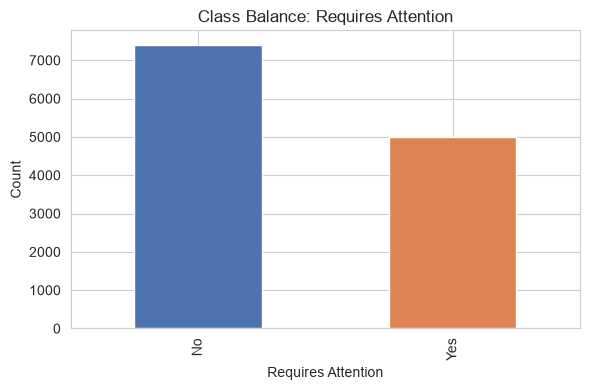

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
pdf["Requires Attention"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Class Balance: Requires Attention")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("output/fig_class_balance.png", dpi=150)
plt.show()


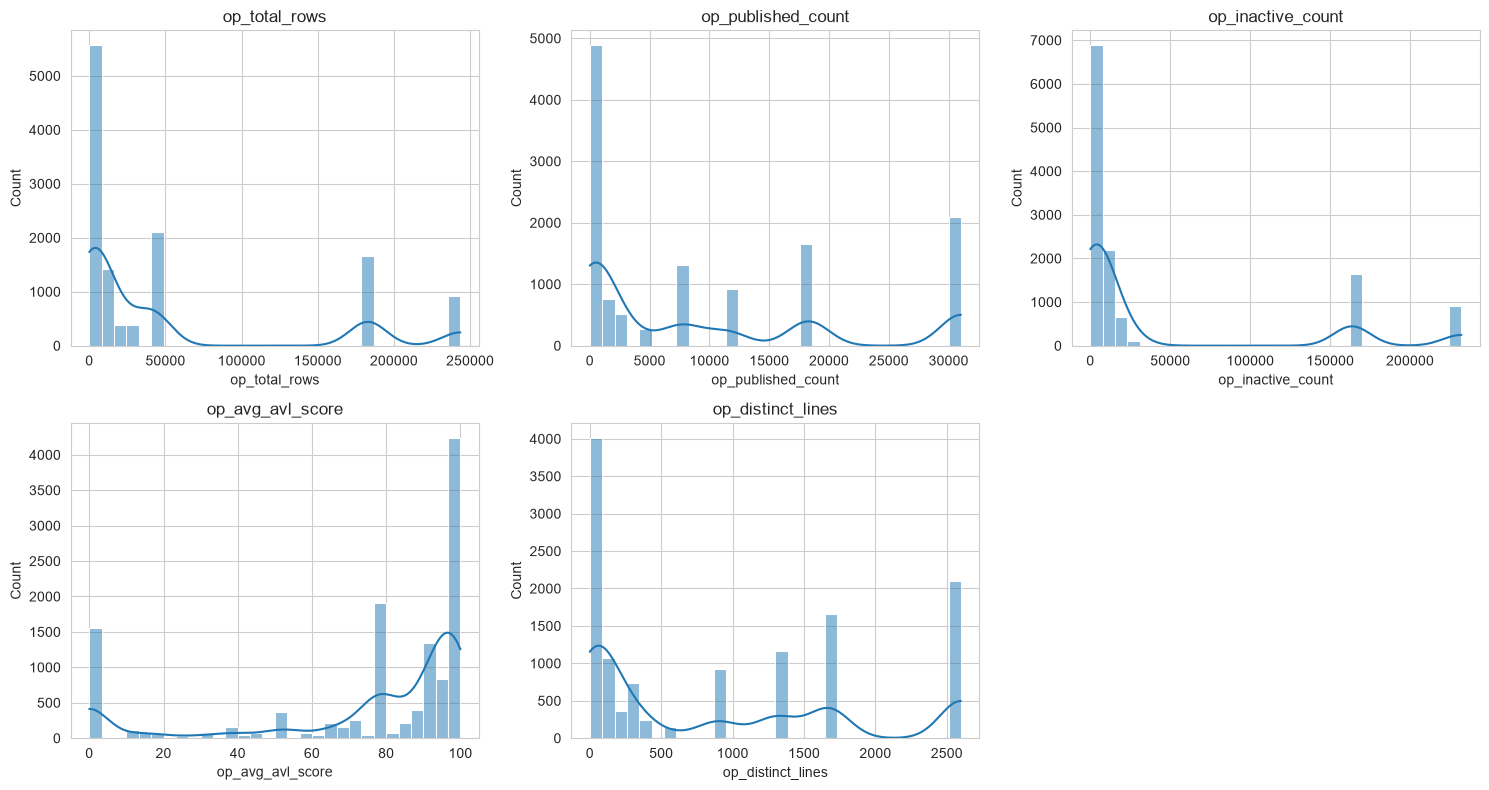

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flatten(), NUMERIC_COLS):
    sns.histplot(pdf[c], bins=30, ax=ax, kde=True)
    ax.set_title(c)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.savefig("output/fig_numeric_distributions.png", dpi=150)
plt.show()


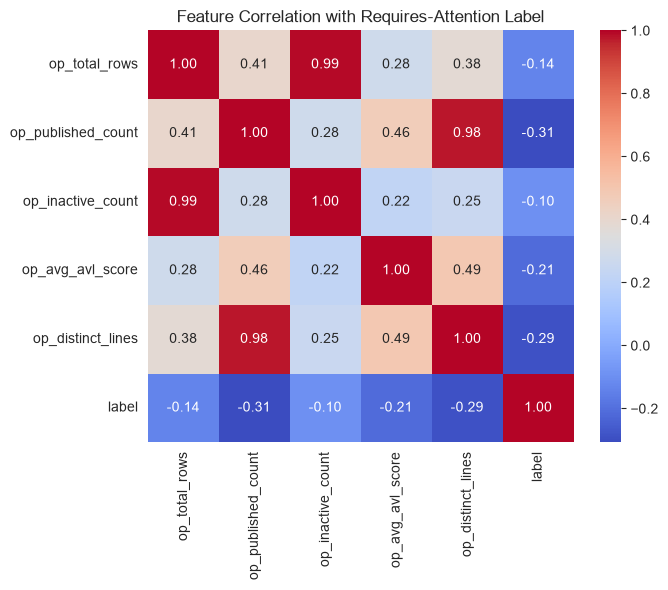

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = pdf[NUMERIC_COLS + ["label"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature Correlation with Requires-Attention Label")
plt.tight_layout()
plt.savefig("output/fig_correlation.png", dpi=150)
plt.show()


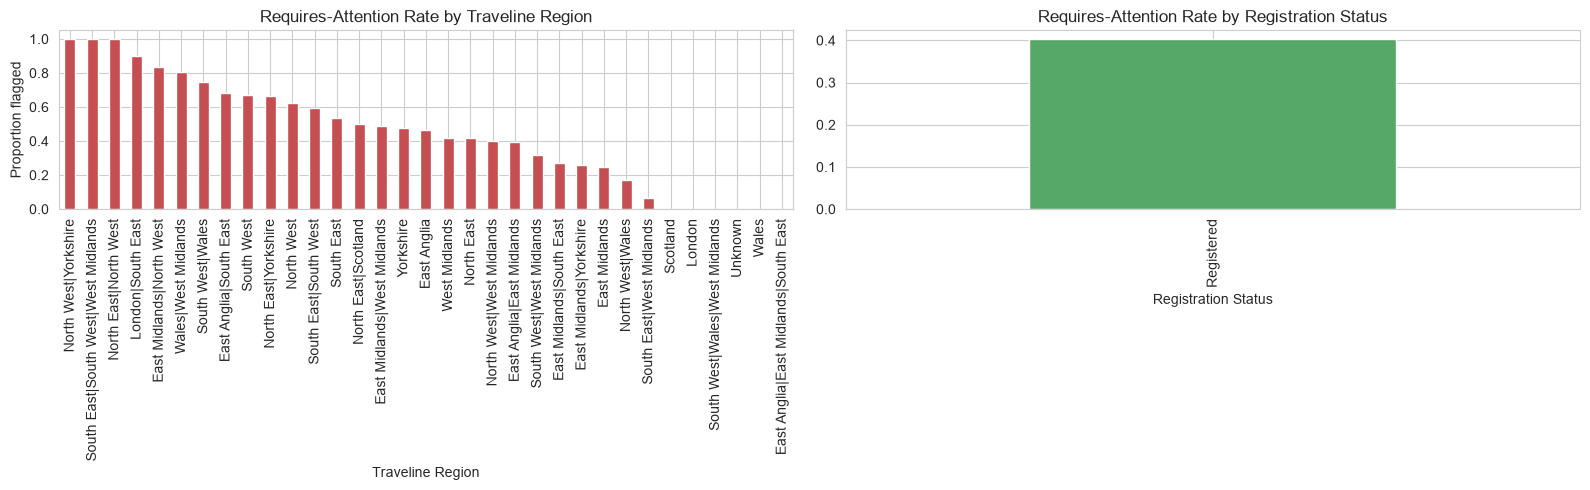

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

region_rate = pdf.groupby("Traveline Region")["label"].mean().sort_values(ascending=False)
region_rate.plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Requires-Attention Rate by Traveline Region")
axes[0].set_ylabel("Proportion flagged")

reg_status_rate = pdf.groupby("Registration Status")["label"].mean().sort_values(ascending=False)
reg_status_rate.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Requires-Attention Rate by Registration Status")

plt.tight_layout()
plt.savefig("output/fig_compliance_by_category.png", dpi=150)
plt.show()


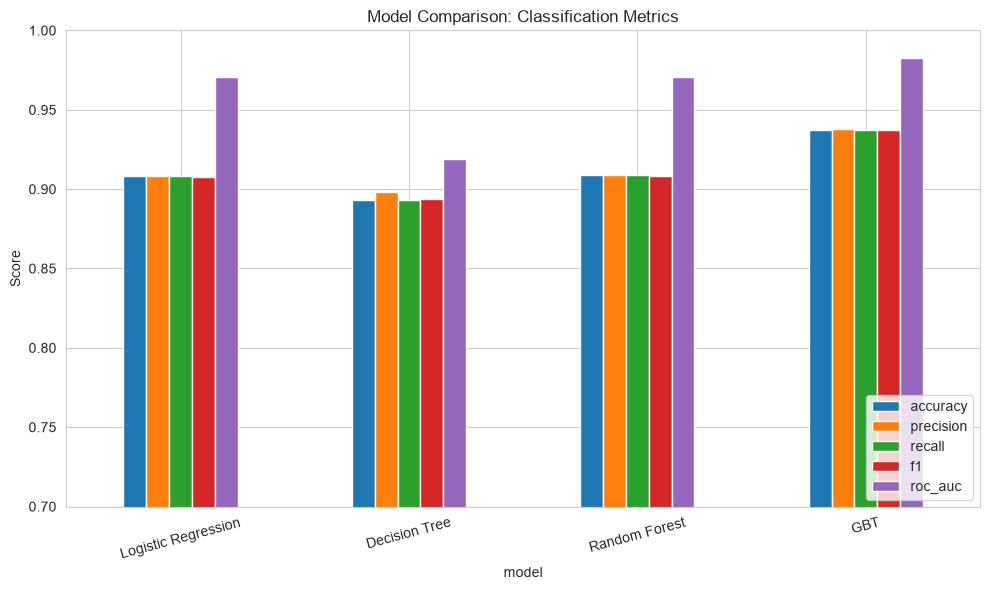

                           f1  train_secs  f1_per_second
model                                                   
Logistic Regression  0.907786    4.189538       0.216679
Decision Tree        0.893832    0.861662       1.037335
Random Forest        0.908588    2.225861       0.408196
GBT                  0.936996   10.458776       0.089589


In [26]:
results_df = pd.DataFrame(results).set_index("model")
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

fig, ax = plt.subplots(figsize=(10, 6))
results_df[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison: Classification Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0.7, 1.0)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("output/fig_model_comparison.png", dpi=150)
plt.show()

# Model Efficiency metric from the brief: F1 per second of training
results_df["f1_per_second"] = results_df["f1"] / results_df["train_secs"]
print(results_df[["f1", "train_secs", "f1_per_second"]])


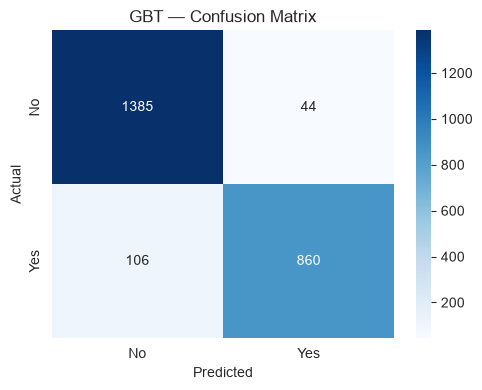

In [31]:
rf_predictions = fitted_models["GBT"].transform(test)
pred_pdf = rf_predictions.select("label", "prediction").toPandas()

cm = confusion_matrix(pred_pdf["label"], pred_pdf["prediction"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("GBT — Confusion Matrix")
plt.tight_layout()
plt.savefig("output/fig_confusion_matrix.png", dpi=150)
plt.show()


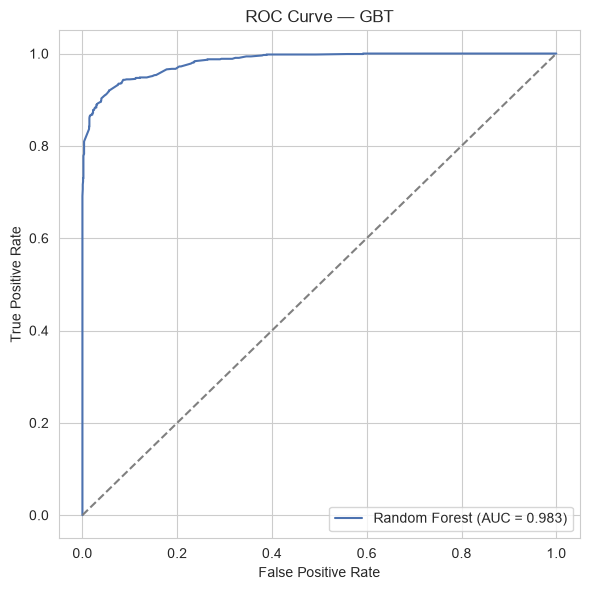

In [33]:
rf_prob_pdf = rf_predictions.select("label", vector_to_array("probability").alias("prob_arr")).toPandas()
rf_prob_pdf["prob_yes"] = rf_prob_pdf["prob_arr"].apply(lambda x: x[1])

fpr, tpr, _ = roc_curve(rf_prob_pdf["label"], rf_prob_pdf["prob_yes"])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})", color="#4C72B0")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — GBT")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("output/fig_roc_curve.png", dpi=150)
plt.show()


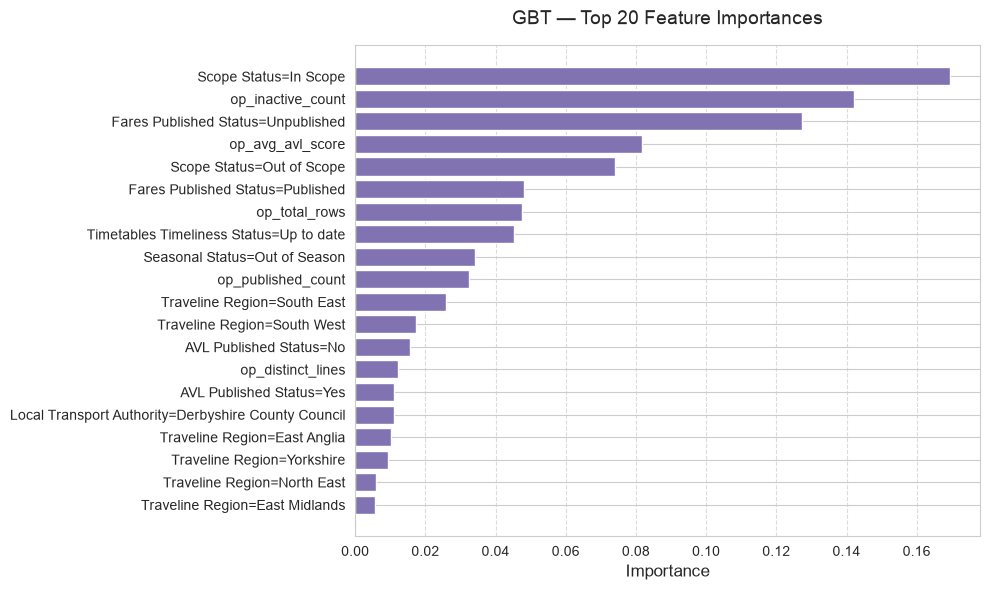

In [36]:
rf_model = fitted_models["GBT"]
importances = rf_model.featureImportances.toArray()

# Pull the fitted StringIndexer stages back out of the pipeline
# (they are the first len(CATEGORICAL_COLS) stages, in the order we built them).
fitted_indexers = pipeline_model.stages[:len(CATEGORICAL_COLS)]

expanded_feature_names = []
for col_name, fitted_indexer in zip(CATEGORICAL_COLS, fitted_indexers):
    expanded_feature_names += [f"{col_name}={label}" for label in fitted_indexer.labels]
feature_names = expanded_feature_names + NUMERIC_COLS

assert len(feature_names) == len(importances), (
    f"feature_names ({len(feature_names)}) and importances ({len(importances)}) length mismatch"
)

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=True)
top_n = 20
top_imp_df = imp_df.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_imp_df["feature"], top_imp_df["importance"], color="#8172B2")
ax.set_title(f"GBT — Top {top_n} Feature Importances", fontsize=14, pad=15)
ax.set_xlabel("Importance", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("output/fig_feature_importance.png", dpi=150)
plt.show()


## 7. Architecture Diagram

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")

boxes = [
    "Data Ingestion\n(8 BODS catalogues,\nPySpark, explicit schema\non 795k-row table)",
    "Cleaning &\nFeature Engineering\n(null handling, joins,\ngroupBy/agg, broadcast join)",
    "ML Pipeline\n(StringIndexer,\nOneHotEncoder,\nVectorAssembler, Scaler)",
    "Model Training\n(LogReg, DT, RF, GBT\ncompared on 5 metrics)",
    "Evaluation &\nVisualisation\n(matplotlib/seaborn,\nSQLite export)",
]

n = len(boxes)
box_w, box_h = 2.2, 1.6
gap = 0.6
start_x = 0.2

for i, text in enumerate(boxes):
    x = start_x + i * (box_w + gap)
    rect = plt.Rectangle((x, 1), box_w, box_h, facecolor="#4C72B0", edgecolor="black", alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + box_w / 2, 1 + box_h / 2, text, ha="center", va="center",
            fontsize=9, color="white", wrap=True)
    if i < n - 1:
        ax.annotate("", xy=(x + box_w + gap - 0.05, 1 + box_h / 2),
                    xytext=(x + box_w + 0.05, 1 + box_h / 2),
                    arrowprops=dict(arrowstyle="->", lw=2, color="black"))

ax.set_xlim(0, start_x + n * (box_w + gap))
ax.set_ylim(0, 3)
ax.set_title("Pipeline Architecture: BODS Operator Compliance Benchmarking", fontsize=12)
plt.tight_layout()
plt.savefig("output/fig_architecture_diagram.png", dpi=150)
plt.show()


## 8. Full-Table Scoring & Database Export

In [ ]:
# Re-run the SAME fitted pipeline (indexers/encoders/assembler/scaler bundled
# together in pipeline_model) over every row, not just the 20% test split,
# then score with the trained Random Forest model.
featurized_full = pipeline_model.transform(ml_table_filled)
full_predictions = fitted_models["Gradient Boosted Trees"].transform(featurized_full)

pred_export_df = full_predictions.select(
    "org_key", "Organisation Name", "Traveline Region", "Registration Status",
    "Requires Attention", "label", "prediction",
    vector_to_array("probability").alias("prob_arr"),
).withColumn("risk_probability", F.col("prob_arr")[1]).drop("prob_arr")

pred_pandas = pred_export_df.toPandas()

conn = sqlite3.connect("output/bods_processed.db")
pred_pandas.to_sql("predictions", conn, if_exists="replace", index=False)
conn.close()
print("Exported", len(pred_pandas), "predictions to output/bods_processed.db (table: predictions)")


## 9. Operator Segmentation (K-Means Clustering)

In [ ]:
cluster_input = operator_features.withColumn(
    "op_published_ratio", F.col("op_published_count") / F.col("op_total_rows")
).fillna(0, subset=["op_avg_avl_score", "op_published_ratio"])

# log1p (log(1+x)) handles zeros safely and compresses the multi-order-of-magnitude
# spread in raw counts, so a few mega-operators stop dominating cluster distance.
cluster_input = (
    cluster_input
    .withColumn("log_total_rows", F.log1p("op_total_rows"))
    .withColumn("log_distinct_lines", F.log1p("op_distinct_lines"))
)

cluster_numeric_cols = [
    "log_total_rows", "op_published_ratio", "op_avg_avl_score", "log_distinct_lines",
]

cluster_assembler = VectorAssembler(inputCols=cluster_numeric_cols, outputCol="cluster_features_raw", handleInvalid="skip")
cluster_scaler = StandardScaler(inputCol="cluster_features_raw", outputCol="cluster_features", withMean=True, withStd=True)

stage = cluster_assembler.transform(cluster_input)
cluster_ready = cluster_scaler.fit(stage).transform(stage)


In [ ]:
evaluator = ClusteringEvaluator(featuresCol="cluster_features", metricName="silhouette")

for k in [2, 3, 4, 5]:
    km = KMeans(featuresCol="cluster_features", k=k, seed=42)
    model = km.fit(cluster_ready)
    preds = model.transform(cluster_ready)
    score = evaluator.evaluate(preds)
    print(f"k={k}  silhouette={score:.3f}")


In [ ]:
best_k = 3
kmeans_final = KMeans(featuresCol="cluster_features", k=best_k, seed=42)
kmeans_model = kmeans_final.fit(cluster_ready)
clustered = kmeans_model.transform(cluster_ready)

print("Cluster sizes:")
clustered.groupBy("prediction").count().orderBy("prediction").show()

print("Cluster profiles (average of RAW, unscaled features per cluster — this is what you name them from):")
clustered.groupBy("prediction").agg(
    F.avg("op_total_rows").alias("avg_total_rows"),
    F.avg("op_published_ratio").alias("avg_published_ratio"),
    F.avg("op_avg_avl_score").alias("avg_avl_score"),
    F.avg("op_distinct_lines").alias("avg_distinct_lines"),
).orderBy("prediction").show()


In [ ]:
clustered_pdf = clustered.select(
    "Operator", "prediction", "op_total_rows", "op_published_ratio", "op_avg_avl_score", "op_distinct_lines"
).toPandas()

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    clustered_pdf["op_published_ratio"], clustered_pdf["op_avg_avl_score"],
    c=clustered_pdf["prediction"], cmap="viridis", s=60, alpha=0.7,
)
ax.set_xlabel("Published Ratio")
ax.set_ylabel("Average AVL Match Score")
ax.set_title("Operator Segmentation (K-Means Clusters)")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig("output/fig_operator_clusters.png", dpi=150)
plt.show()


In [ ]:
cluster_names = {0: "Small Compliant Publishers", 1: "At-Risk Operators", 2: "Large Established Operators"}

cluster_export = clustered.select(
    "Operator", "prediction", "op_total_rows", "op_published_ratio",
    "op_avg_avl_score", "op_distinct_lines",
).withColumnRenamed("prediction", "cluster_id").toPandas()

cluster_export["cluster_name"] = cluster_export["cluster_id"].map(cluster_names)
cluster_export["org_key"] = cluster_export["Operator"].str.upper().str.strip()

conn = sqlite3.connect("output/bods_processed.db")
cluster_export.to_sql("operator_clusters", conn, if_exists="replace", index=False)
conn.close()
print("Exported", len(cluster_export), "operator clusters to output/bods_processed.db (table: operator_clusters)")


In [ ]:
import numpy as np

T = 100                     # numTrees for Random Forest
n = train.count()
m = len(feature_names)      # from your feature-importance cell
log_n = np.log(n)

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Log(n)", "Features (m)", "Samples (n) \u00f7 1000", "Trees (T)"]
plot_values = [log_n, m, n / 1000, T]     # n scaled down so it's visible alongside T/m
true_values = [log_n, m, n, T]

bars = ax.barh(labels, plot_values, color=["#8FBFA8", "#6FA8C9", "#7FD3C6", "#F08080"])
for bar, val in zip(bars, true_values):
    ax.text(bar.get_width() + max(plot_values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,.1f}" if val < 100 else f"{val:,.0f}", va="center")

ax.set_title("Training Complexity: O(T \u00d7 n \u00d7 m \u00d7 log n)")
ax.set_xlabel("Value (scaled)")
plt.tight_layout()
plt.savefig("output/fig_training_complexity.png", dpi=150)
plt.show()

In [ ]:
model_order = ["Logistic Regression", "Decision Tree", "Random Forest", "GBT"]
times = [next(r["train_secs"] for r in results if r["model"] == mdl) for mdl in model_order]
relative_times = [t / times[0] for t in times]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_order, relative_times, color=["#F4B6B6", "#C6A8E0", "#B6D6C6", "#F4C6D8"])
for bar, rel in zip(bars, relative_times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(relative_times) * 0.02,
            f"{rel:.1f}x", ha="center", fontweight="bold")

ax.set_title("Training Time Comparison")
ax.set_ylabel("Relative Training Time")
plt.tight_layout()
plt.savefig("output/fig_training_time_comparison.png", dpi=150)
plt.show()

In [ ]:
import time

rf_model = fitted_models["Gradient Boosted Trees"]

# test already has pipeline output columns baked in - rebuild the raw
# (pre-transform) version of those same rows so timing reflects a real
# feature-transform + predict pass, not a second pass over already-featurized data.
raw_test = ml_table_filled.join(test.select("org_key").distinct(), on="org_key", how="inner")
n_test = raw_test.count()

t0 = time.time()
featurized_test = pipeline_model.transform(raw_test)
featurized_test.count()          # force evaluation
t1 = time.time()

predicted_test = rf_model.transform(featurized_test)
predicted_test.count()           # force evaluation
t2 = time.time()

feature_ms = (t1 - t0) / n_test * 1000
predict_ms = (t2 - t1) / n_test * 1000
total_ms = feature_ms + predict_ms

fig, ax = plt.subplots(figsize=(8, 5))
stages, stage_times = ["Feature Pipeline", "Model Prediction"], [feature_ms, predict_ms]
bars = ax.bar(stages, stage_times, color=["#F4C6C6", "#F0D0E8"])
for bar, val in zip(bars, stage_times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(stage_times) * 0.02,
            f"{val:.2f}ms", ha="center", fontweight="bold")
ax.set_title(f"Inference Complexity: O(T \u00d7 log d) \u2248 {total_ms:.2f}ms/operator")
ax.set_ylabel("Time (ms)")
plt.tight_layout()
plt.savefig("output/fig_inference_complexity.png", dpi=150)
plt.show()

In [ ]:
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
sizes, train_times = [], []

for frac in fractions:
    sample_df = train.sample(fraction=frac, seed=42)
    n_sample = sample_df.count()
    start = time.time()
    RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, maxDepth=10).fit(sample_df)
    elapsed = time.time() - start
    sizes.append(n_sample)
    train_times.append(elapsed)
    print(f"fraction={frac:.2f}  n={n_sample:6d}  time={elapsed:.2f}s")

relative_times = [t / train_times[0] for t in train_times]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, relative_times, marker="o", color="#6A5ACD", linewidth=2, label="Training Time")
ax.fill_between(sizes, relative_times, alpha=0.15, color="#6A5ACD")
ax.axvline(sizes[-1], color="red", linestyle="--", label="Current dataset")
ax.set_title("Scalability: Training Time vs Dataset Size")
ax.set_xlabel("Training Samples")
ax.set_ylabel("Relative Training Time")
ax.legend()
plt.tight_layout()
plt.savefig("output/fig_scalability.png", dpi=150)
plt.show()